# 7. External Season 3 Validation

Notebook 7 performs the out-of-time validation step. The previous notebooks used Season 2 to construct the opportunity panel, replay reserve/floor policies, screen them with guardrails, estimate model-assisted OPE diagnostics, study heterogeneity, and run robustness checks. Those results justify validation, but they do not yet show that the selected policy generalizes beyond the development window.

This notebook replays the same frozen policy catalog on Season 3. The goal is not to claim a randomized treatment effect. It is a temporal holdout check: if the priority policy is truly a credible validation candidate, it should remain attractive when the same replay contract is applied to a later season.



## What This Notebook Creates

Inputs from earlier notebooks:

- `metadata/reserve_policy_price_landscape.csv`
- `metadata/reserve_policy_registry.csv`
- `metadata/reserve_policy_effects.csv`
- `metadata/season2_outcome_density.csv`
- Season 3 panel shards from notebook 0, when available

Generated analysis artifacts:

- `metadata/season3_policy_daily_effects.csv`
- `metadata/season3_priority_policy_daily_validation.csv`
- `metadata/season2_vs_season3_distribution_summary.csv`
- `metadata/season2_vs_season3_daily_distribution.csv`
- `metadata/season2_vs_season3_policy_transfer.csv`
- `metadata/season3_priority_policy_validation.csv`

Generated figures:

- `artifacts/figures/13_season2_vs_season3_distribution.png`
- `artifacts/figures/13_season2_vs_season3_transfer.png`
- `artifacts/figures/13_season3_priority_validation_combined.png`

The notebook reuses existing Season 3 panel shards if they are present. If they are missing, it rebuilds the needed Season 3 panels from the local iPinYou archive and writes the shards for future runs.



## Reproducibility Setup

The validation run is deterministic conditional on the raw archive, the Season 3 date set, and the frozen policy catalog. Set `FULL_RUN = True` to validate on every available Season 3 date. Set it to `False` only for a quick smoke test.



In [1]:
from __future__ import annotations

import sys
from pathlib import Path


def find_repo_root(start: Path) -> Path:
    for candidate in [start, *start.parents]:
        if (candidate / "src").exists() and (candidate / "pyproject.toml").exists():
            return candidate
    raise FileNotFoundError("Could not locate repository root containing src/ and pyproject.toml")

REPO_ROOT = find_repo_root(Path.cwd().resolve())
SRC_ROOT = REPO_ROOT / "src"
if str(SRC_ROOT) not in sys.path:
    sys.path.insert(0, str(SRC_ROOT))

print(f"Repository root: {REPO_ROOT}")



Repository root: /home/apex/Documents/ranking_sys/notebooks/writing/ads_marketplace_auction_experimentation/marketplace-policies-code


In [2]:
from IPython.display import Image, display

from checks import ArtifactRepository
from config import PaperConfig, ProjectPaths, RawPipelineConfig
from data_access import IpinYouArchive, Workspace
from external_validation import ExternalValidationBuilder
from figures import FigureRenderer
from panel_builder import OpportunityPanelBuilder
from policy_catalog import ReservePolicyCatalog
from progress import ProgressLogger



In [3]:
SOURCE_ROOT = REPO_ROOT / "artifacts" / "workspace"
OUTPUT_ROOT = REPO_ROOT / "artifacts"
FULL_RUN = True
RUN_SEASON3_VALIDATION = True

paths = ProjectPaths.from_cli(SOURCE_ROOT, OUTPUT_ROOT)
paths.ensure_output_dirs()
repository = ArtifactRepository(paths)
repository.require_layout()
workspace = Workspace(paths.source_root)
progress = ProgressLogger(enabled=True)

config = RawPipelineConfig(
    data_root=REPO_ROOT / "data",
    workspace_root=SOURCE_ROOT,
    full_run=FULL_RUN,
    clean_workspace=False,
)
paper_config = PaperConfig()

required = [
    paths.metadata_dir / "reserve_policy_price_landscape.csv",
    paths.metadata_dir / "reserve_policy_effects.csv",
    paths.metadata_dir / "season2_outcome_density.csv",
]
missing = [path.relative_to(REPO_ROOT) for path in required if not path.exists()]
if missing:
    raise FileNotFoundError(
        "Run notebooks 0 and 3 before Season 3 validation. "
        f"Missing: {missing}"
    )

print("Required Season 2 policy and distribution artifacts are present.")



Required Season 2 policy and distribution artifacts are present.


## Frozen Policy Catalog

The Season 3 validation must use the same policy definitions selected from Season 2. The catalog below is parameterized by the Season 2 positive-floor quantiles stored in `reserve_policy_price_landscape.csv`. This avoids tuning floors on Season 3.



In [4]:
price_landscape = repository.read_csv("reserve_policy_price_landscape.csv")
price_values = price_landscape.set_index("stat")["value"].to_dict()
price_quantiles = {
    "q25": float(price_values["positive_floor_q25"]),
    "q50": float(price_values["positive_floor_q50"]),
    "q75": float(price_values["positive_floor_q75"]),
}
catalog = ReservePolicyCatalog(price_quantiles)
registry = catalog.registry()
registry.head(10)



,policy_id,policy_family,description,floor_rule,supported_by_replay_contract,policy_number,policy_label
0,logged_floor_status_quo,baseline,Logged floor exactly as observed.,logged,True,P0,Logged Floor Status Quo
1,uniform_raise_05pct,uniform_percent,Raise every logged floor by 5 percent.,logged * 1.05,True,P1,Uniform Raise 05Pct
2,uniform_raise_10pct,uniform_percent,Raise every logged floor by 10 percent.,logged * 1.10,True,P2,Uniform Raise 10Pct
3,uniform_raise_15pct,uniform_percent,Raise every logged floor by 15 percent.,logged * 1.15,True,P3,Uniform Raise 15Pct
4,uniform_raise_20pct,uniform_percent,Raise every logged floor by 20 percent.,logged * 1.20,True,P4,Uniform Raise 20Pct
5,uniform_raise_30pct,uniform_percent,Raise every logged floor by 30 percent.,logged * 1.30,True,P5,Uniform Raise 30Pct
6,add_5_all_floors,absolute_increment,Add 5 price units to every floor.,logged + 5,True,P6,Add 5 All Floors
7,add_10_all_floors,absolute_increment,Add 10 price units to every floor.,logged + 10,True,P7,Add 10 All Floors
8,add_20_all_floors,absolute_increment,Add 20 price units to every floor.,logged + 20,True,P8,Add 20 All Floors
9,min_positive_floor_q25,minimum_positive_floor,Lift positive floors below q25 (10.00) to q25.,"max(logged, 10.00) if logged > 0",True,P9,Min Positive Floor Q25


## Build Season 3 Validation Artifacts

The external validation builder applies the frozen policy catalog to the Season 3 holdout window. For each Season 3 day and policy, it computes the same replay quantities used in Season 2: retained impressions, counterfactual yield, retained clicks, retained conversions, and retained value proxy. It then aggregates the daily rows and compares Season 2 and Season 3 policy lifts.



In [5]:
archive = IpinYouArchive(config.archive_path)
panel_builder = OpportunityPanelBuilder(archive, workspace, config, progress=progress)
validation_builder = ExternalValidationBuilder(workspace, config, catalog, progress=progress)

if RUN_SEASON3_VALIDATION:
    validation_builder.build_season3_validation(panel_builder, catalog)

transfer = repository.read_csv("season2_vs_season3_policy_transfer.csv")
priority = repository.read_csv("season3_priority_policy_validation.csv")
daily_priority = repository.read_csv("season3_priority_policy_daily_validation.csv")
distribution_summary = repository.read_csv("season2_vs_season3_distribution_summary.csv")

print(f"Season 3 policy transfer rows: {len(transfer):,}")
print(f"Season 3 priority validation days: {daily_priority['event_date'].nunique():,}")
priority



[     0.2s] Starting: season-three out-of-time validation replay
[     0.3s] Loading existing season-three panel shard for date 20131019: season3_panel_20131019.parquet.
[     0.8s] Loading existing season-three panel shard for date 20131020: season3_panel_20131020.parquet.
[     1.2s] Loading existing season-three panel shard for date 20131021: season3_panel_20131021.parquet.
[     3.4s] Loading existing season-three panel shard for date 20131022: season3_panel_20131022.parquet.
[     5.1s] Loading existing season-three panel shard for date 20131023: season3_panel_20131023.parquet.
[     7.0s] Loading existing season-three panel shard for date 20131024: season3_panel_20131024.parquet.
[     9.7s] Loading existing season-three panel shard for date 20131025: season3_panel_20131025.parquet.
[    12.6s] Loading existing season-three panel shard for date 20131026: season3_panel_20131026.parquet.
[    13.4s] Loading existing season-three panel shard for date 20131027: season3_panel_20131027

,policy_id,policy_family,season2_pct_yield_lift,season3_pct_yield_lift,season3_rank,season3_retained_impression_share,season3_value_proxy_retention,policy_label,season2_rank,yield_lift_transfer_gap,rank_shift_season3_minus_season2,season3_click_retention,season3_conversion_retention,passes_positive_yield_lift,passes_fill_guardrail,passes_value_guardrail,passes_top_rank_guardrail,validation_verdict
0,hybrid_q75_if_gap_100,hybrid_minimum_margin,0.476604,0.438722,1,1.0,1.0,Q75 Margin-Gated Floor,1,-0.037882,0,1.0,1.0,True,True,True,True,passes_external_replay_validation


## Season 2 vs Season 3 Data Distribution

Before interpreting the holdout replay, check whether the validation window has comparable operational scale. The table and figure below compare the constructed Season 2 analysis panel with the Season 3 holdout panel on total opportunities, fill rate, click rate, conversion rate, and daily opportunity volume.



In [6]:
distribution_summary.assign(
    bid_opportunities_millions=lambda d: d["bid_opportunities"] / 1_000_000,
    mean_daily_opportunities_millions=lambda d: d["mean_daily_opportunities"] / 1_000_000,
)[[
    "season",
    "days_observed",
    "bid_opportunities_millions",
    "fill_rate",
    "click_rate_per_opportunity",
    "conversion_rate_per_opportunity",
    "mean_daily_opportunities_millions",
]]



,season,days_observed,bid_opportunities_millions,fill_rate,click_rate_per_opportunity,conversion_rate_per_opportunity,mean_daily_opportunities_millions
0,Season 2,7,53.289330,0.228758,0.000164,0.000007,7.612761
1,Season 3,9,10.566743,0.296431,0.000255,0.000050,1.174083


Wrote Season 2 vs Season 3 distribution figure to artifacts/figures/13_season2_vs_season3_distribution.png


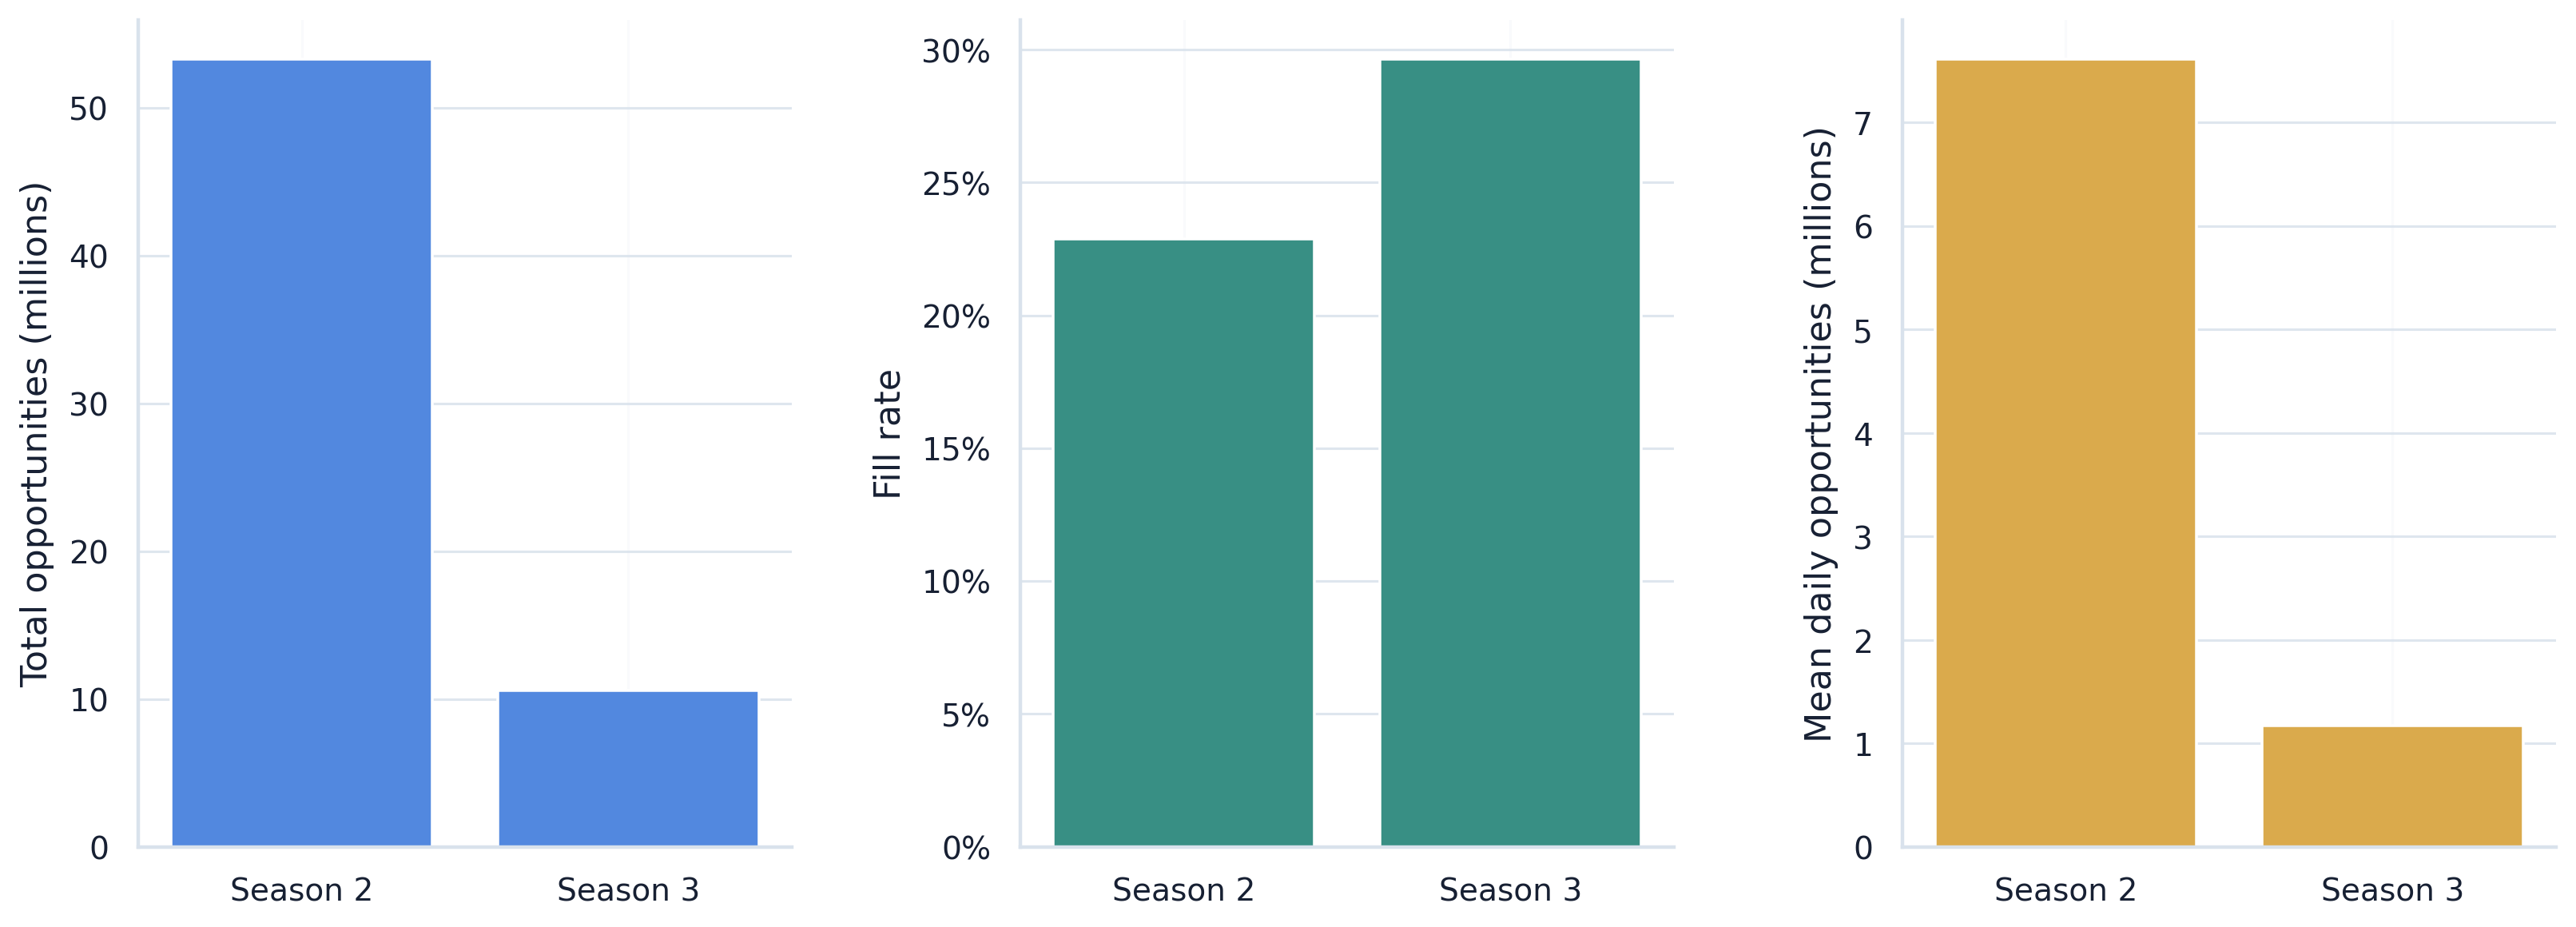

In [7]:
renderer = FigureRenderer(repository, paths.figure_dir, paper_config, progress=progress)

distribution_path = renderer.plot_season2_vs_season3_distribution()
print(f"Wrote Season 2 vs Season 3 distribution figure to {distribution_path.relative_to(REPO_ROOT)}")
display(Image(filename=str(distribution_path)))



## Policy Transfer from Season 2 to Season 3

The transfer plot asks whether policies that looked attractive in Season 2 remain attractive in Season 3. Points near the diagonal have similar replay lift in both seasons. Points above or below the diagonal change their replay lift in the holdout season. The priority policy is annotated so the paper can directly state whether the selected policy remains the leading replay candidate out of time.



In [8]:
transfer_display = (
    transfer.sort_values("season3_rank")[[
        "policy_id",
        "policy_label",
        "season2_rank",
        "season2_pct_yield_lift",
        "season3_rank",
        "season3_pct_yield_lift",
        "season3_retained_impression_share",
        "season3_value_proxy_retention",
        "yield_lift_transfer_gap",
    ]]
)
transfer_display.head(12)



,policy_id,policy_label,season2_rank,season2_pct_yield_lift,season3_rank,season3_pct_yield_lift,season3_retained_impression_share,season3_value_proxy_retention,yield_lift_transfer_gap
0,hybrid_q75_if_gap_100,Q75 Margin-Gated Floor,1,0.476604,1,0.438722,1.000000,1.000000,-0.037882
1,min_positive_floor_q75,Min Positive Floor Q75,2,0.355075,2,0.299696,1.000000,1.000000,-0.055380
2,zero_and_low_floor_to_q50,Zero And Low Floor To Q50,3,0.101179,3,0.123098,1.000000,1.000000,0.021918
3,hybrid_q50_if_gap_50,Hybrid Q50 If Gap 50,3,0.101179,3,0.123098,1.000000,1.000000,0.021918
6,min_positive_floor_q50,Min Positive Floor Q50,6,0.072978,4,0.085755,1.000000,1.000000,0.012776
5,add_20_all_floors,Add 20 All Floors,5,0.097433,5,0.081185,0.999515,0.998617,-0.016248
4,margin_gap_100_add_20,Margin Gap 100 Add 20,4,0.097883,6,0.075945,1.000000,1.000000,-0.021937
7,uniform_raise_30pct,Uniform Raise 30Pct,7,0.069190,7,0.040003,0.994047,0.988178,-0.029187
9,margin_gap_50_add_10,Margin Gap 50 Add 10,9,0.040727,8,0.037351,1.000000,1.000000,-0.003376
10,add_10_all_floors,Add 10 All Floors,10,0.040310,9,0.036979,0.999837,0.999623,-0.003331


Wrote Season 2 to Season 3 transfer figure to artifacts/figures/13_season2_vs_season3_transfer.png


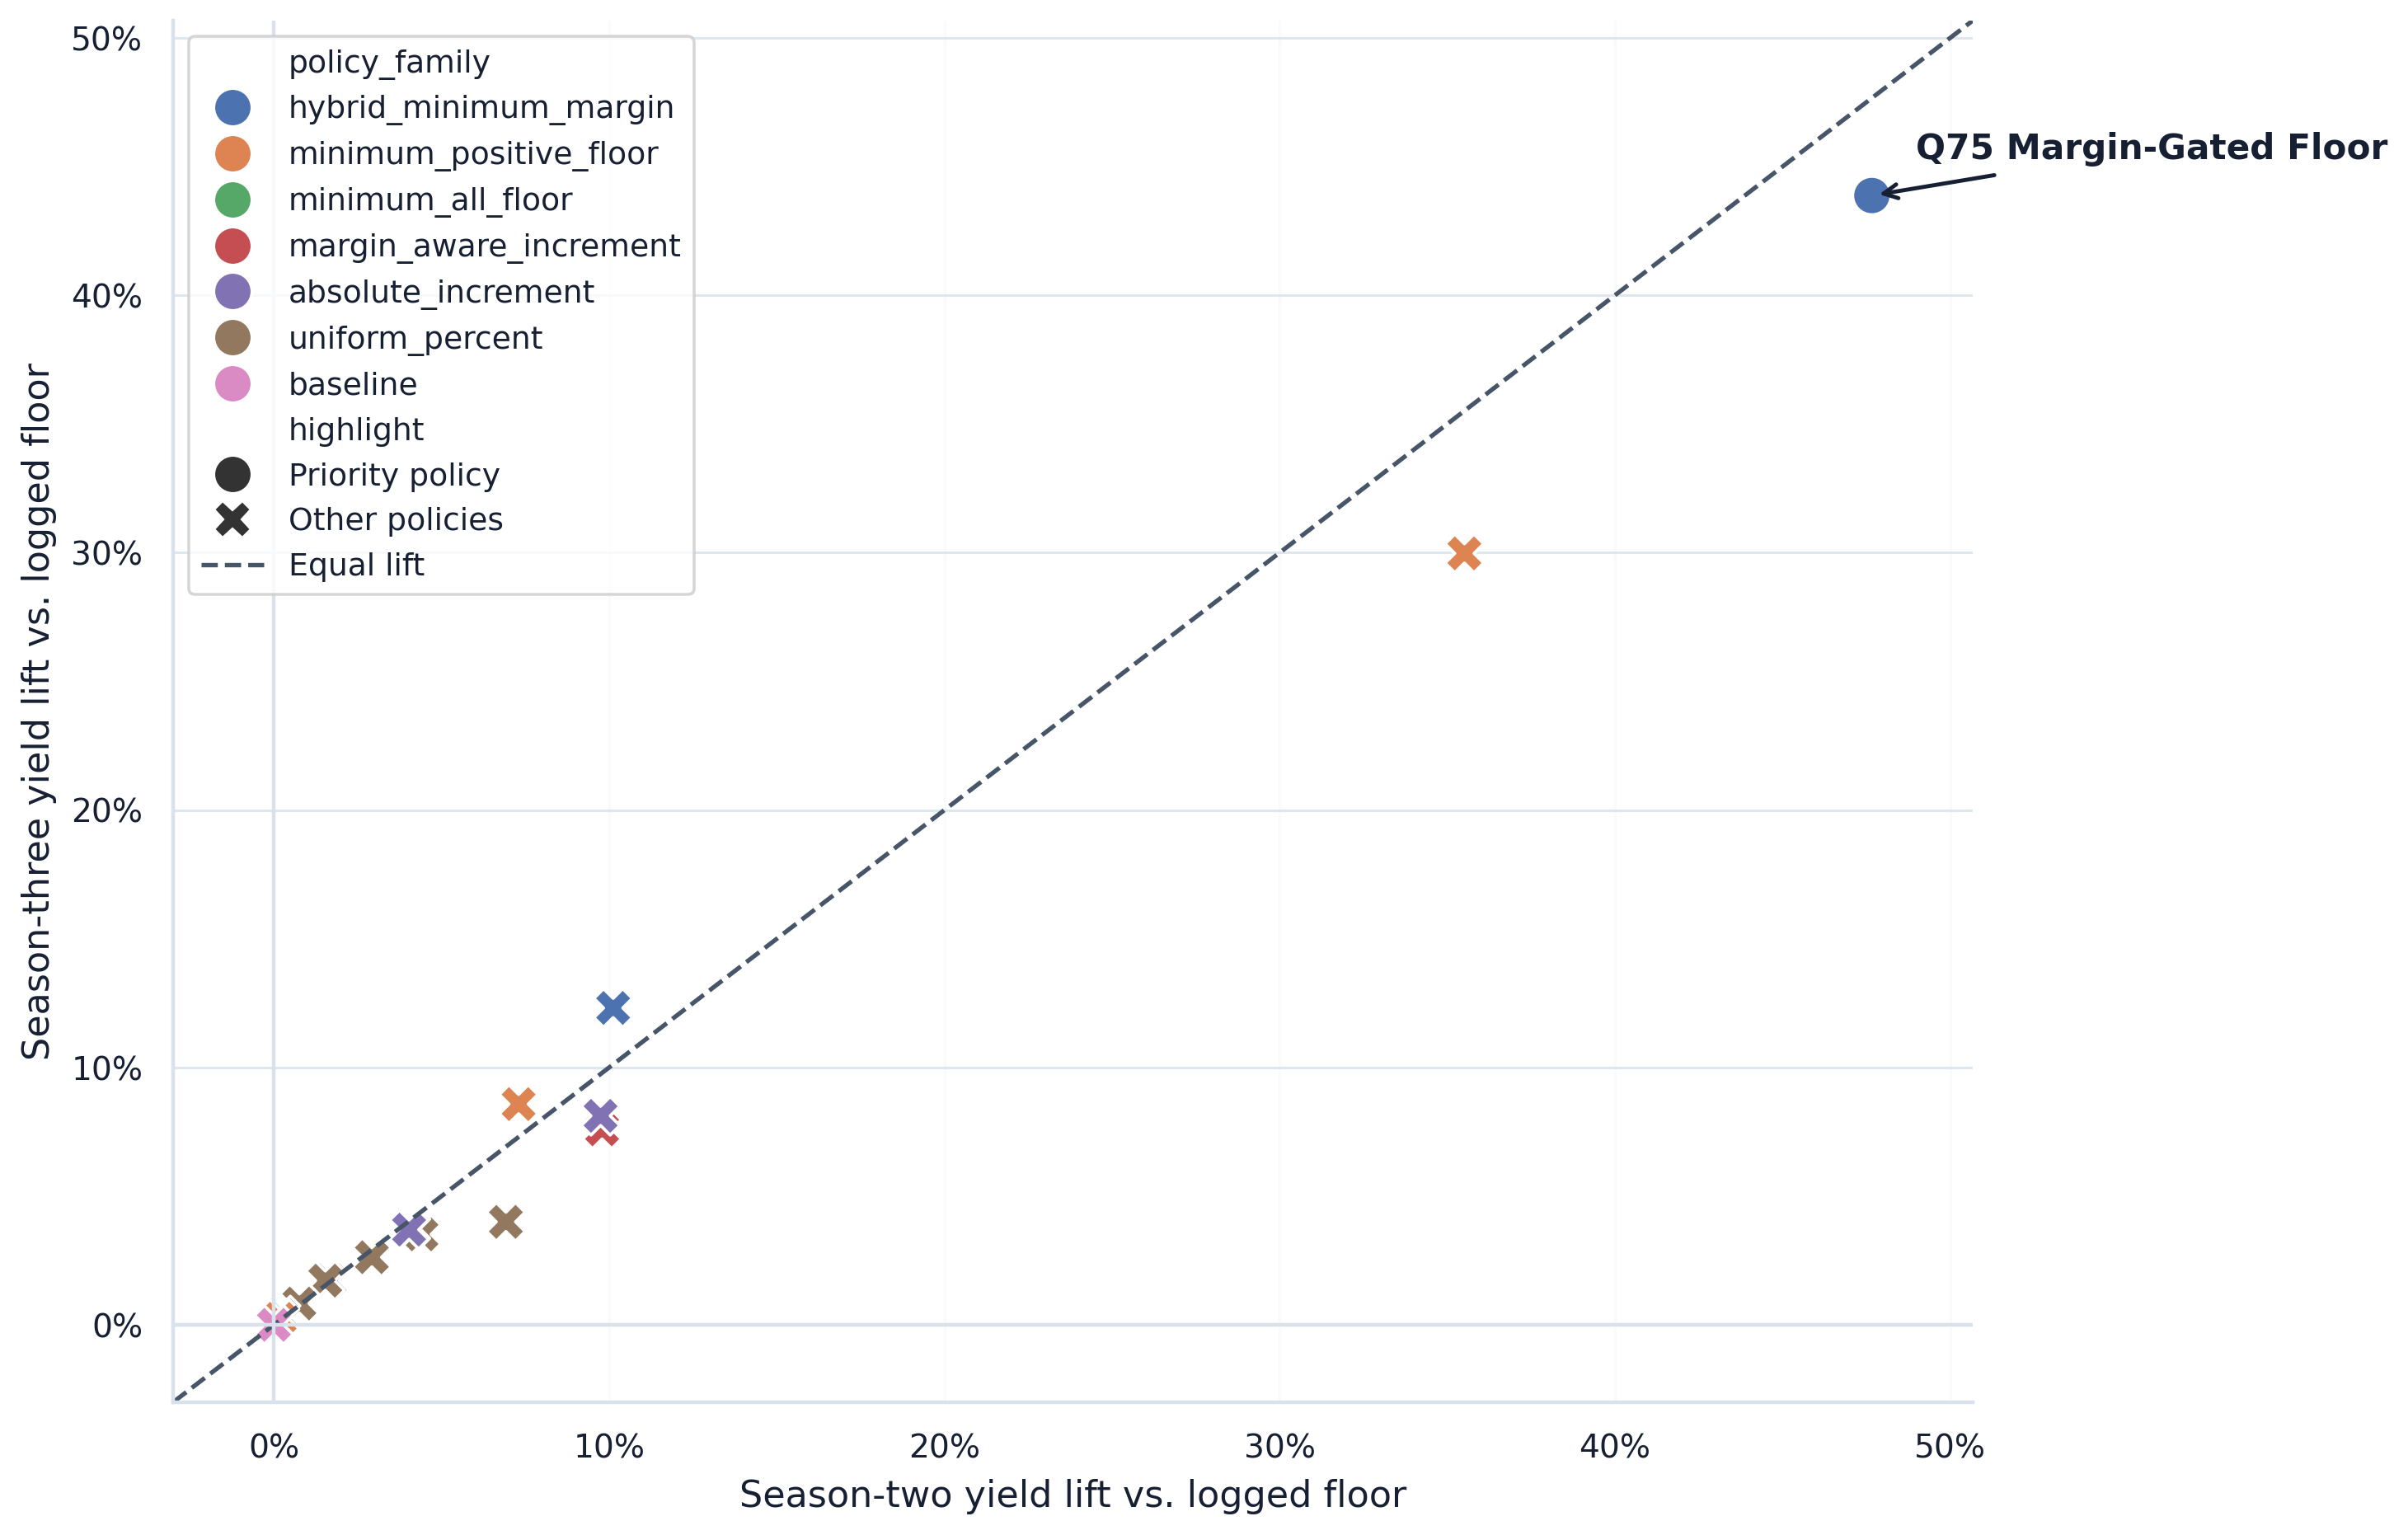

In [9]:
transfer_path = renderer.plot_season3_transfer()
print(f"Wrote Season 2 to Season 3 transfer figure to {transfer_path.relative_to(REPO_ROOT)}")
display(Image(filename=str(transfer_path)))



## Priority-Policy Daily Validation and Holdout Guardrails

Aggregate holdout lift can hide day-level fragility. The daily validation panel therefore plots the priority policy's Season 3 yield lift against the logged-floor baseline on each observed validation day. The paired guardrail panel summarizes whether the same holdout replay preserves the quantities that matter for a validation candidate: positive yield lift, retained impressions, retained clicks, retained conversions, and retained value proxy.



In [10]:
daily_priority[[
    "event_date",
    "opportunities",
    "observed_filled_impressions",
    "retained_impressions",
    "daily_yield_lift_pct",
    "retained_impression_share",
]].sort_values("event_date")



,event_date,opportunities,observed_filled_impressions,retained_impressions,daily_yield_lift_pct,retained_impression_share
0,2013-10-19,352766,227827,227827,0.441171,1.0
1,2013-10-20,326830,214022,214022,0.428679,1.0
2,2013-10-21,1547653,844982,844982,0.412160,1.0
3,2013-10-22,1212083,678805,678805,0.399669,1.0
4,2013-10-23,1578272,225696,225696,0.415827,1.0
5,2013-10-24,2184015,245284,245284,0.612179,1.0
6,2013-10-25,2230333,317424,317424,0.498015,1.0
7,2013-10-26,536934,267960,267960,0.438359,1.0
8,2013-10-27,597857,110311,110311,0.476361,1.0


/home/apex/Documents/ranking_sys/notebooks/writing/ads_marketplace_auction_experimentation/marketplace-policies-code/src/figures.py:1026: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=guardrail_values, x="metric", y="value", palette=colors, ax=ax_guardrails)


Wrote combined Season 3 priority validation figure to artifacts/figures/13_season3_priority_validation_combined.png


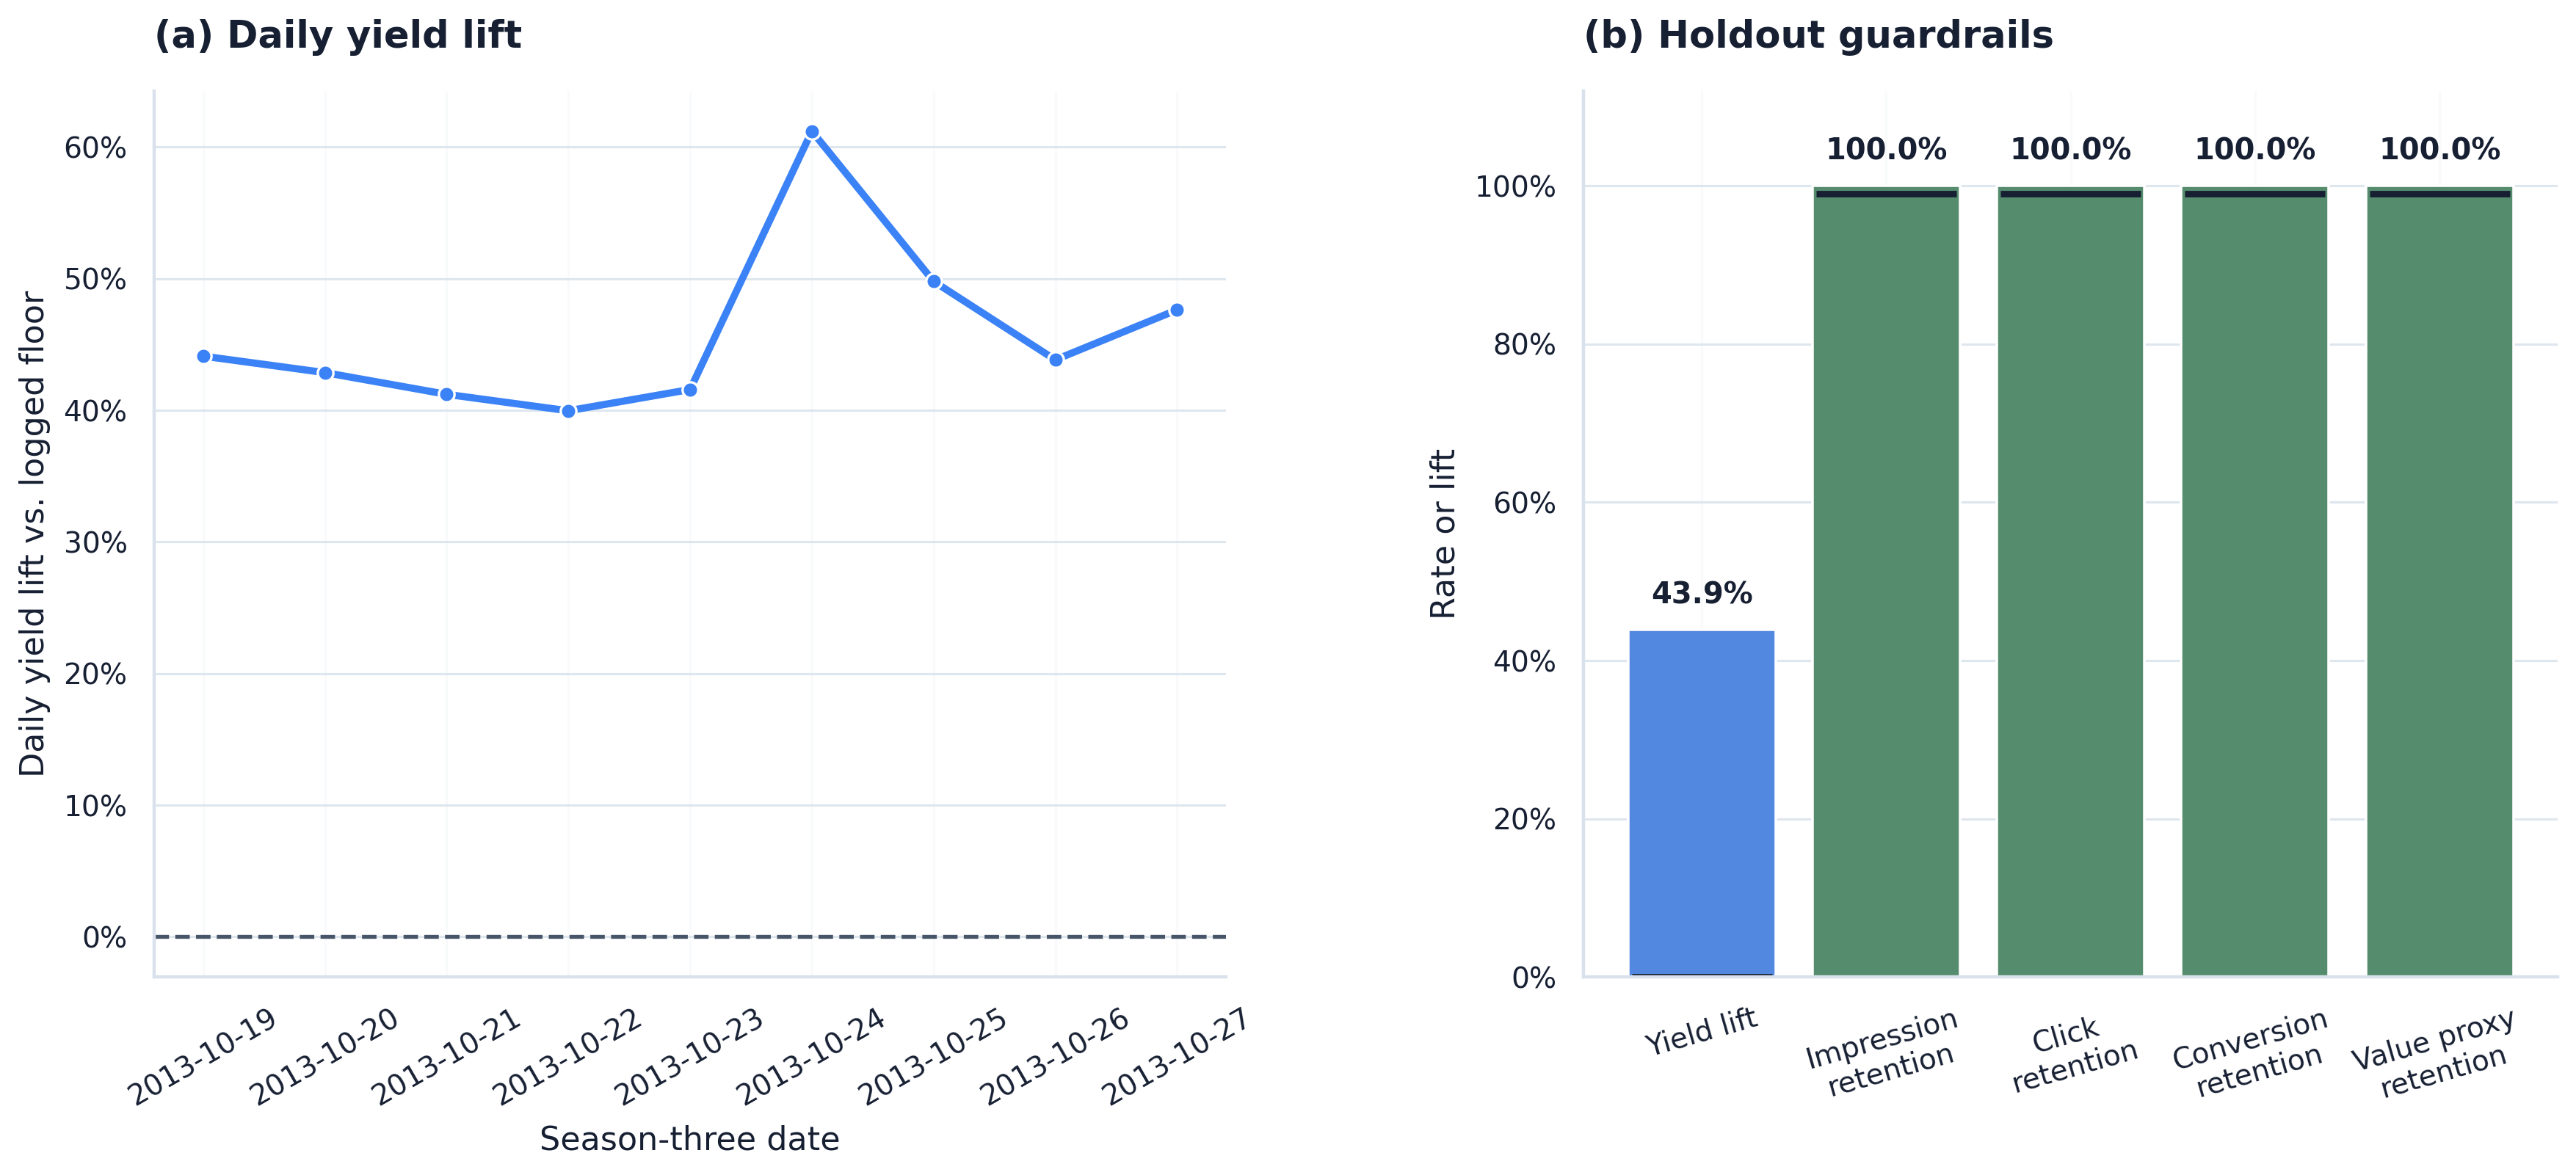

In [11]:
combined_validation_path = renderer.plot_season3_priority_validation_combined()
print(f"Wrote combined Season 3 priority validation figure to {combined_validation_path.relative_to(REPO_ROOT)}")
display(Image(filename=str(combined_validation_path)))



## Holdout Validation Table

The table below records the same holdout validation quantities used in panel (b) and keeps the exact pass/fail fields visible for reproducibility.



In [12]:
priority[[
    "policy_id",
    "season3_rank",
    "season3_pct_yield_lift",
    "season3_retained_impression_share",
    "season3_value_proxy_retention",
    "passes_positive_yield_lift",
    "passes_fill_guardrail",
    "passes_value_guardrail",
    "passes_top_rank_guardrail",
    "validation_verdict",
]]



,policy_id,season3_rank,season3_pct_yield_lift,season3_retained_impression_share,season3_value_proxy_retention,passes_positive_yield_lift,passes_fill_guardrail,passes_value_guardrail,passes_top_rank_guardrail,validation_verdict
0,hybrid_q75_if_gap_100,1,0.438722,1.0,1.0,True,True,True,True,passes_external_replay_validation


In [13]:
# The daily validation and guardrail summary are combined in the figure above.
# The separate renderer remains available for compatibility with older paper builds.



## Interpretation for the Paper

Season 3 validation is the bridge between offline Season 2 evidence and an online experiment recommendation. If the priority policy remains highly ranked, has positive holdout lift, preserves impression and value-proxy retention, and is not driven by a single holdout day, then the evidence for validation becomes stronger. The conclusion is still not direct launch: Season 3 replay is out-of-time, but it still uses the fixed-bid replay contract. The validation result should therefore be used as evidence for shadow logging or controlled switchback design, not as a substitute for online causal measurement.

